In [1]:
import os
import pandas as pd
import random
from PIL import Image

data = []
path = "C:/Users/USER/Documents/Trabajo/Text oritation/SROIE_2019_text_recognition"

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".jpg"):
            file_path = os.path.join(root, file)
            angle = random.randint(-180, 180)
            img = Image.open(file_path).convert("RGB").rotate(angle, expand=True)
            data.append({"path": file_path, "filename": file, "angle": angle, "imagen":img})
df = pd.DataFrame(data)


In [2]:
df_sample = df.sample(frac=0.5,random_state=44).reset_index(drop=True)  # Shuffle the DataFrame
print(df_sample.head())
print("Total images:", len(df))

                                                path  \
0  C:/Users/USER/Documents/Trabajo/Text oritation...   
1  C:/Users/USER/Documents/Trabajo/Text oritation...   
2  C:/Users/USER/Documents/Trabajo/Text oritation...   
3  C:/Users/USER/Documents/Trabajo/Text oritation...   
4  C:/Users/USER/Documents/Trabajo/Text oritation...   

                                   filename  angle  \
0  eb6ddcdb-3f73-478c-8f19-2ff8837ad355.jpg     26   
1  94df59b3-f318-4972-83c5-c3755d551c8d.jpg   -161   
2  6877a6fe-d4e3-49c2-9429-ddb6a3a7444b.jpg   -159   
3  2870b085-c30e-4f2e-9834-5ca2021c469b.jpg     64   
4  6ea22266-eb4d-49c4-92c5-b4ead5ab3e40.jpg    -34   

                                              imagen  
0  <PIL.Image.Image image mode=RGB size=211x134 a...  
1  <PIL.Image.Image image mode=RGB size=386x159 a...  
2  <PIL.Image.Image image mode=RGB size=108x66 at...  
3  <PIL.Image.Image image mode=RGB size=165x303 a...  
4  <PIL.Image.Image image mode=RGB size=92x72 at ...  
Total im

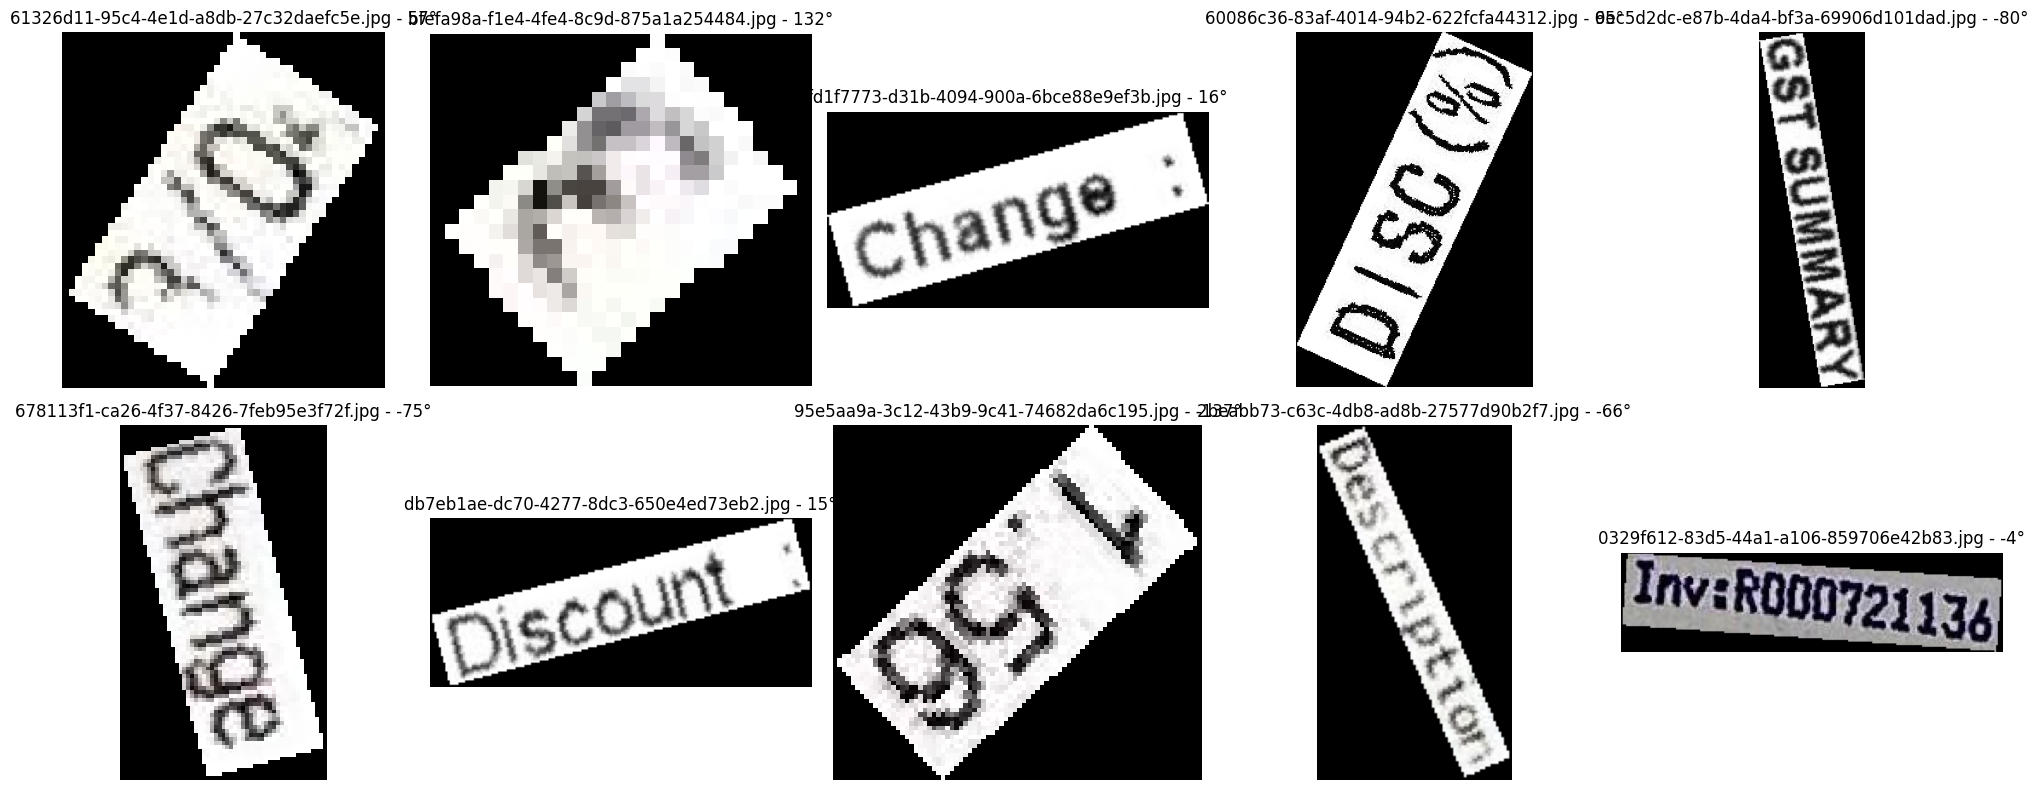

In [3]:
import matplotlib.pyplot as plt

df_show = df.sample(n=10, random_state=42)  # o usa frac=0.1
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, (_, row) in zip(axes.flatten(), df_show.iterrows()):
    ax.imshow(row['imagen'], cmap='gray')
    ax.set_title(f"{row['filename']} - {row['angle']}°")
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import lightning as L
from sklearn.model_selection import train_test_split, KFold
from torchvision import transforms
import numpy as np

class ImageKitAngleDataset(Dataset):
    def __init__(self, images, angles):
        self.images = images
        self.angles = angles  # en grados
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        angle_deg = self.angles[idx]
        img_tensor = self.transform(img)
        angle_rad = np.deg2rad(angle_deg)
        angle_vector = torch.tensor([np.sin(angle_rad), np.cos(angle_rad)], dtype=torch.float32)
        return img_tensor, angle_vector


class MyDataModule(L.LightningDataModule):
    def __init__(self, df, batch_size=64, kfold=5):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.kfold = kfold
        self.images = df["imagen"].tolist()
        self.angles = df["angle"].values.astype(np.float32)

    def prepare_data(self):
        idx = np.arange(len(self.df))
        y = self.angles
        self.X_train_idx, self.X_test_idx, self.y_train, self.y_test = train_test_split(
            idx, y, test_size=0.3, shuffle=True, random_state=42
        )
        self.kfolder = list(KFold(n_splits=self.kfold, shuffle=True, random_state=42).split(self.X_train_idx))

    def setup(self, stage=None, n_fold=0):
        if stage == "fit" or stage is None:
            train_idx, val_idx = self.kfolder[n_fold]
            train_idx = self.X_train_idx[train_idx]
            val_idx = self.X_train_idx[val_idx]
            self.train_dataset = ImageKitAngleDataset([self.images[i] for i in train_idx],
                                                      self.angles[train_idx])
            self.val_dataset = ImageKitAngleDataset([self.images[i] for i in val_idx],
                                                    self.angles[val_idx])

        if stage == "test" or stage is None:
            self.test_dataset = ImageKitAngleDataset([self.images[i] for i in self.X_test_idx],
                                                     self.angles[self.X_test_idx])

        if stage == "predict" or stage is None:
            self.predict_dataset = self.test_dataset

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=4)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4)

    def predict_dataloader(self, data=None):
        if data is None:
            return DataLoader(self.predict_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4)
        else:
            return DataLoader(data, batch_size=self.batch_size, shuffle=False, num_workers=4)


In [ ]:
dataset=MyDataModule(df=df_sample,batch_size=64,kfold=5)
dataset.prepare_data()
dataset.setup()


In [ ]:
print("Train dataset size:", len(dataset.images))

In [ ]:
import torch
import torch.nn as nn
import lightning as L


class MobileNetV2AngleRegressor(L.LightningModule):
    def __init__(
        self, input_dim=1280, lr=1e-4, lambda_reg=0.0001, regularization=None, hidden_units=[16, 16, 16]
    ):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.regularization = regularization
        self.lambda_reg = lambda_reg

        layers = [nn.Flatten()]
        in_features = input_dim
        for units in hidden_units:
            layers.append(nn.Linear(in_features, units))
            nn.LayerNorm(units)
            layers.append(nn.LeakyReLU(negative_slope=0.1))
            in_features = units

        layers.append(nn.Linear(in_features, 2))  # → [sin(θ), cos(θ)]
        self.backbone = nn.Sequential(*layers)

        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.backbone(x)

    def configure_optimizers(self):
        if self.regularization == "L2":
            return torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.lambda_reg)
        else:
            return torch.optim.Adam(self.parameters(), lr=self.lr)

    def compute_regularization_loss(self):
        reg_loss = 0.0
        if self.regularization == "L1":
            for param in self.parameters():
                reg_loss += torch.sum(torch.abs(param))
        elif self.regularization == "L2":
            for param in self.parameters():
                reg_loss += torch.sum(param ** 2)
        return self.lambda_reg * reg_loss

    def angle_error_degrees(self, y_hat, y):
        angle_pred = torch.atan2(y_hat[:, 0], y_hat[:, 1]) * (180 / torch.pi)
        angle_true = torch.atan2(y[:, 0], y[:, 1]) * (180 / torch.pi)
        error = torch.abs(angle_pred - angle_true) % 360
        error = torch.where(error > 180, 360 - error, error)
        return error.mean()

    def training_step(self, batch, batch_idx):
        x, y = batch  # y: [batch, 2] → [sin(θ), cos(θ)]
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y.float())
        if self.regularization in ["L1", "L2"]:
            loss += self.compute_regularization_loss()

        angle_err_deg = self.angle_error_degrees(y_hat, y)
        self.log("train_loss", loss, on_step=True, on_epoch=True)
        self.log("train_angle_error_deg", angle_err_deg, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y.float())
        angle_err_deg = self.angle_error_degrees(y_hat, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_angle_error_deg", angle_err_deg, on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y.float())
        angle_err_deg = self.angle_error_degrees(y_hat, y)
        self.log("test_loss", loss, on_epoch=True)
        self.log("test_angle_error_deg", angle_err_deg, on_epoch=True)
        return loss

    def predict_step(self, batch, batch_idx):
        x = batch
        preds = self(x)
        return preds


In [ ]:
lambda_ = 0.001
epochs = 1000  # Number of epochs for training
# hidden_units = [254, 254, 254]
# regul = "L1"
hiddens_units = [[64]*4,[128]*4,[256]*4,[512]*4]
reguls = ["L1", "L2"]

In [ ]:
import torch
print(torch.cuda.is_available())  # ¿True?
print(torch.version.cuda)         # ¿"11.8", "12.1", etc?|
#print(torch.cuda.get_device_name(0))  # ¿Detecta tu GPU?
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import os
import pandas as pd

df_metrics = pd.DataFrame()

for regul in reguls:
    
    for hidden_units in hiddens_units:
        results = []  # [losses]
        for i in range(dataset.kfold):
            model = MobileNetV2AngleRegressor(
                hidden_units=hidden_units,
                lambda_reg=lambda_,
                regularization=regul,
            )
            early_stop_callback = L.pytorch.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=10,
            )
            checkpoint_callback = L.pytorch.callbacks.ModelCheckpoint(
                save_top_k=2,
                save_last=True,
                monitor="val_loss",
                mode="min",
            )
            callbacks = [early_stop_callback, checkpoint_callback]
            name = ",".join([str(n) for n in hidden_units])
            path = f"{name}_{regul}"
            fold_dir = os.path.join("checkpoints", path)
            os.makedirs(fold_dir, exist_ok=True)
            trainer = L.Trainer(
                max_epochs=epochs,
                callbacks=callbacks,
                accelerator="gpu" if device.type == "cuda" else "cpu",
                devices=1,
                default_root_dir=fold_dir,
            )
            dataset.setup(stage="fit", n_fold=i)
            trainer.fit(
                model,
                train_dataloaders=dataset.train_dataloader(),
                val_dataloaders=dataset.val_dataloader(),
            )
            result_val = trainer.validate(
                model,
                dataloaders=dataset.val_dataloader(),
                ckpt_path="best",
            )
            result_test = trainer.test(
                model,
                dataloaders=dataset.test_dataloader(),
                ckpt_path="best",
            )
            print(result_test)
            results.append(result_test[0]["test_angle_error_deg"])
        # Agregar columnas al DataFrame
        col_loss = f"{name}_{regul}_loss_deg"
        df_metrics[col_loss] = results

In [ ]:
print(df_metrics)